# Business Problem: Predict restaurant sales (Order Total) and identify key revenue drivers.

In [279]:
!pip install dash


In [398]:
import pandas as pd
import seaborn as sns
import os
from category_encoders import OneHotEncoder
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge # noqa F401
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
#sb.set()
from dash import Dash, dcc, html
from dash.dependencies import Input, Output

# Preparing Data

In [409]:
def wrangle(filePath):
    #importing data
    df = pd.read_csv(filePath)
    
    #hadling missing values for the item column
    df['Item'] = df['Item'].fillna('Unknown')
    
    #handling missing values for payment method
    df['Payment Method'] = (df['Payment Method'].fillna(df['Payment Method'].mode()[0]))
    
    #handling missing values for price
    df['Price'] = (df['Price'].fillna(df['Price'].median()))
    
    #handling missing values for quanity
    df['Quantity'] = (df['Quantity'].fillna(df['Quantity'].median()))
    
    #handling missing values and reconstructing order total
    df['Order Total'] = (df['Order Total'].fillna(df['Price'] * df['Quantity']))
    
    #Renaming Order total to revenue
    df.rename(columns = {'Order Total': 'Revenue'}, inplace = True)
    
    #RECONSTRUCTING ORDER DATE
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    df['Order_year'] = df['Order Date'].dt.year
    df['Order_month'] = df['Order Date'].dt.strftime('%b')
    df['Order_day'] = df['Order Date'].dt.day
    df['Quarter'] = df['Order Date'].dt.quarter
    
    #drop mullicollinearity
    df.drop(columns =[ 'Order Date', 'Order ID', 'Customer ID'], inplace = True)
    
    #Subset data: Remove outliers from Price
    low, high = df["Price"].quantile([0.1, 0.9])
    mask_price = df["Price"].between(low, high)
    df = df[mask_price]
    
    return df

In [410]:
df = wrangle('restaurant_sales_data.csv')

print('dataframe_shape', df.shape)
df.head()

dataframe_shape (15470, 10)


,Category,Item,Price,Quantity,Revenue,Payment Method,Order_year,Order_month,Order_day,Quarter
0,Side Dishes,Side Salad,3.0,1.0,3.0,Credit Card,2023,Dec,21,4
1,Side Dishes,Mashed Potatoes,4.0,3.0,12.0,Digital Wallet,2023,May,19,2
2,Main Dishes,Grilled Chicken,15.0,4.0,60.0,Credit Card,2023,Sep,27,3
3,Drinks,Unknown,5.0,2.0,5.0,Credit Card,2022,Aug,9,3
4,Main Dishes,Pasta Alfredo,12.0,4.0,48.0,Cash,2022,May,15,2


In [283]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17534 entries, 0 to 17533
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        17534 non-null  object        
 1   Item            17534 non-null  object        
 2   Price           17534 non-null  float64       
 3   Quantity        17534 non-null  float64       
 4   Revenue         17534 non-null  float64       
 5   Order Date      17534 non-null  datetime64[ns]
 6   Payment Method  17534 non-null  object        
 7   Order_year      17534 non-null  int64         
 8   Order_month     17534 non-null  object        
 9   Order_day       17534 non-null  int64         
 10  Quarter         17534 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(4)
memory usage: 1.5+ MB


In [380]:
df.nunique()

Category            5
Item               24
Price              11
Quantity            5
Revenue            41
Order Date        730
Payment Method      3
Order_year          2
Order_month        12
Order_day          31
Quarter             4
dtype: int64

In [285]:
#Checking missing values
df.isnull().sum()

Category          0
Item              0
Price             0
Quantity          0
Revenue           0
Order Date        0
Payment Method    0
Order_year        0
Order_month       0
Order_day         0
Quarter           0
dtype: int64

In [286]:
#Checking missing values percentage
df.isnull().mean() *100


Category          0.0
Item              0.0
Price             0.0
Quantity          0.0
Revenue           0.0
Order Date        0.0
Payment Method    0.0
Order_year        0.0
Order_month       0.0
Order_day         0.0
Quarter           0.0
dtype: float64

In [287]:
#checking for duplicate. 
df.duplicated().sum()

536

# Business Insight Exploration data analysis

In [339]:
#Total Revenue actulaized

df['Revenue'].sum()

283342.5

In [340]:
revenue_by_category = (df.groupby('Category')['Revenue'].sum()).sort_values(ascending = False).reset_index()
revenue_by_category= pd.DataFrame(revenue_by_category)

#Main dish contributes almost half of the revenue
revenue_by_category

,Category,Revenue
0,Main Dishes,101265.0
1,Starters,61274.0
2,Desserts,58278.0
3,Side Dishes,41674.0
4,Drinks,20851.5


In [341]:
#Revenue realized by method of payment
revenue_by_payment = (df.groupby('Payment Method')['Revenue'].sum()).sort_values(ascending = False).reset_index()
revenue_by_payment = pd.DataFrame(revenue_by_payment)

#Credit card is the most preferred payment method as compare to cash and digital wallet
revenue_by_payment

,Payment Method,Revenue
0,Credit Card,106177.0
1,Cash,89699.5
2,Digital Wallet,87466.0


In [342]:
#Revenue realized by the of each year
revenue_by_year = (df.groupby('Order_year')['Revenue'].sum()).sort_values(ascending = False).reset_index()
revenue_by_year = pd.DataFrame(revenue_by_year)

#Credit card is the most preferred payment method as compare to cash and digital wallet
revenue_by_year

,Order_year,Revenue
0,2022,144063.0
1,2023,139279.5


In [344]:
#MONTHLY REVENUE TREND FOR 2022

year_mask_2022 = df['Order_year'] == 2022
df_order_year_2022 = df[year_mask_2022]

monthly_revenue_22=df_order_year_2022.groupby(["Order_month"])["Revenue"].sum()#.sort_values()

monthly_revenue_22 = pd.DataFrame(monthly_revenue_22).reset_index()

# Define the correct order for months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
 #Convert 'Month' column to a categorical type with the specified order
monthly_revenue_22['Order_month'] = pd.Categorical(monthly_revenue_22['Order_month'], categories=month_order, ordered=True)

# Sort the DataFrame by the 'Month' column
monthly_revenue_22 = monthly_revenue_22.sort_values('Order_month')

monthly_revenue_22

,Order_month,Revenue
4,Jan,11225.5
3,Feb,10848.5
7,Mar,12516.0
0,Apr,11744.0
8,May,12004.0
6,Jun,12977.0
5,Jul,11728.0
1,Aug,12178.0
11,Sep,11536.0
10,Oct,13555.0


In [347]:
#MONTHLY REVENUE TREND FOR 2023

year_mask_2023 = df['Order_year'] == 2023
df_order_year_2023 = df[year_mask_2023]

monthly_revenue_23=df_order_year_2023.groupby(["Order_month"])["Revenue"].sum()#.sort_values()

monthly_revenue_23 = pd.DataFrame(monthly_revenue_23).reset_index()

# Define the correct order for months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
 #Convert 'Month' column to a categorical type with the specified order
monthly_revenue_23['Order_month'] = pd.Categorical(monthly_revenue_23['Order_month'], categories=month_order, ordered=True)

# Sort the DataFrame by the 'Month' column
monthly_revenue_23 = monthly_revenue_23.sort_values('Order_month')

monthly_revenue_23

,Order_month,Revenue
4,Jan,11594.0
3,Feb,10300.5
7,Mar,12406.5
0,Apr,11029.0
8,May,12441.0
6,Jun,11786.5
5,Jul,11691.0
1,Aug,12415.0
11,Sep,11473.0
10,Oct,11883.5


In [372]:
top_10_items = (df.groupby('Item')['Quantity'].sum()).sort_values(ascending = False).head(10).reset_index().drop(0)
top_10_items

,Item,Quantity
1,Pasta Alfredo,3094.0
2,Side Salad,2932.0
3,Ice Cream,2929.0
4,French Fries,2721.0
5,Grilled Chicken,2492.0
6,Mashed Potatoes,2374.0
7,Chocolate Cake,2348.0
8,Coca Cola,2282.0
9,Cheese Fries,2061.0


# VISUALISATION

In [316]:
fig = px.bar(
    revenue_by_category,
    x = 'Category',
    y = 'Revenue',
    color='Revenue',
    title = 'Revenue by Category: (Identify highest earning category.)'

)

fig.show()

In [321]:
fig = px.pie(
    revenue_by_category,
    names = 'Category',
    values = 'Revenue',
    
)

fig.update_layout(
    title = 'Category revenue by shares (Show contribution of each category by percentage.)'
)


fig.show()

In [317]:
fig = px.bar(
    revenue_by_payment,
    x = 'Payment Method',
    y = 'Revenue',
    #color='Revenue',
    title = 'Revenue by Payment Method: (Understand customer payment preferences.)'

)

fig.show()

In [345]:
fig = px.line(
    monthly_revenue_22,
    x= 'Order_month',
    y= 'Revenue',
    #color='Order_month',
    markers=True
    
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Revenue",
    title = 'Monthly Revenue Trend for 2022 (Identify seasonality and sales patterns.)'
)

fig.show()

In [348]:
fig = px.line(
    monthly_revenue_23,
    x= 'Order_month',
    y= 'Revenue',
    #color='Order_month',
    markers=True
    

)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Revenue",
    title = 'Monthly Revenue Trend for 2023 (Identify seasonality and sales patterns.)'
)

fig.show()

In [422]:
fig = px.histogram(
    df,
    x="Price",
    color = 'Price'
    
)
fig.update_layout(
    xaxis_title="Item Prices",
    yaxis_title="Frequency",
    title = 'Price Distribution (Identify pricing concentration and outliers.)'
)


In [337]:
fig = px.scatter(
    df,
    x= 'Price',
    y = 'Revenue',
    trendline = 'ols'

)

fig.update_layout(
    xaxis_title="Item Prices",
    yaxis_title="Revenue",
    title = 'Price vs Revenue (Examining relationship between product pricing and sales.)'
)

fig.data[1].line.color = 'red'
fig.show()

In [378]:
fig = px.bar(
    top_10_items,
    x= 'Quantity',
    y= 'Item',
    orientation='h',
    text ='Quantity',
    color = 'Quantity'
    
)
fig.update_layout(
    xaxis_title="Sales",
    yaxis_title="Products",
    title = 'Top 10 Selling Items (Identify best-selling products.)',
    yaxis={"categoryorder": "total ascending"}
)


fig.show()

# splitting data

In [411]:
target = 'Revenue'
feature = df.drop(columns = target).columns
X = df[feature]
y = df[target]

#splitting my dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12376, 9)
y_train shape: (12376,)
X_test shape: (3094, 9)
y_test shape: (3094,)


# Building Model

In [412]:
#bASELINE

y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
baseline_mae = mean_absolute_error(y_train, y_pred_baseline)

print("Mean apt Revenue:", y_mean)
print("Baseline MAE:", baseline_mae)

Mean apt Revenue: 18.34187136393019
Baseline MAE: 10.683436953793002


In [413]:
#ITERATE: CREATING A PIPELINE TTHAT WILL USE RandomForest AS MY PREDICTOR

model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(),
    RandomForestRegressor(random_state=42)
)

model.fit(X_train,y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['Category', 'Item', 'Payment Method',
                                     'Order_month'],
                               use_cat_names=True)),
                ('simpleimputer', SimpleImputer()),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [414]:
#CREATE A LIST OF PREDICTIONS USING MY TRAIN DATA
y_pred_training_revenue = model.predict(X_train)

y_pred_training_revenue[:4]

array([ 3. , 30. , 12. ,  2.5])

In [415]:
mae_training = mean_absolute_error(y_train, y_pred_training_revenue)
print("Training MAE:", round(mae_training, 2))


Training MAE: 0.09


In [418]:
r2 = r2_score(y_train, y_pred_training_revenue)
r2

0.9979279085518147

In [419]:
#CREATE A LIST OF PREDICTIONS USING MY TEST DATA

y_pred_test_revenue = model.predict(X_test)

y_pred_test_revenue[:4]

array([ 9.  , 12.  , 15.  , 24.98])

In [421]:
#comparing the actual y_test Revenue with y_predict test revenue

comparison = pd.DataFrame({
    "Actual_Revenue": y_test,
    'predicted_Revenue': y_pred_test_revenue
    
}).reset_index(drop=True)

comparison.head(5)

,Actual_Revenue,predicted_Revenue
0,9.0,9.00
1,12.0,12.00
2,15.0,15.00
3,24.0,24.98
4,9.0,9.00


# SELECTING THE IMPORTANT FEATURES

In [423]:
features = model.named_steps['onehotencoder'].get_feature_names_out()
importances = model.named_steps['randomforestregressor'].feature_importances_

In [425]:
f_importance = pd.Series((importances), index = features).sort_values(ascending = False)

In [429]:
f_importance.head()

Quantity                0.422150
Category_Main Dishes    0.301372
Price                   0.256980
Item_Pasta Alfredo      0.006641
Order_day               0.004418
dtype: float64

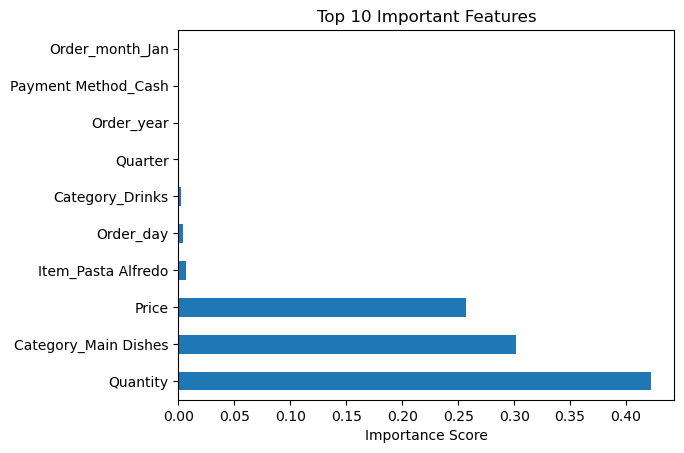

In [430]:
f_importance.sort_values(ascending = False).head(10).plot(
    kind='barh'
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.show()